# Ensemble Stacking Model

**Disclaimer:** I did end up still using XG Boost, but used 2 newer models not used as often as asked for in HW instructions (catboost and lightgbm, still used xgboost because it keeps preforming really well for me)

**Metric:** Balanced accuracy 
**Goal:** Combine XGBoost, LightGBM, and CatBoost using stacking and compare it to evaluate whether the ensemble beats any individual model.

## Why ensemble?

XGBoost, LightGBM, and CatBoost all scored somewhat similarly but get there differently. XGBoost builds depth wise trees with leaf wise growth and LightGBM builds leaf wise trees with unbalanced and deeper branches. CatBoost builds symmetric trees and handles categoriclas. Hoping that when combined these models might be stronger together, ensembling thusfar hasn't worked for me, but hoping with the new models and features added it will.

## Two approaches tested

Method A is simple averaging: take the predicted probabilities from all three models and average them.

Method B is stacking: train a model on those same predictions to learn which model to trust more for which class. 

In [13]:
# importing libraries
# adding helpful lists for me to use later on in code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED   = 42
TARGET = 'Irrigation_Need'
ORDER  = ['Low', 'Medium', 'High']

CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'
]

## 1. Load Data

In [14]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (630000, 21)
Test shape:  (270000, 20)


## 2. Feature Engineering

All features from previous notebooks and the CatBoost notebook are included here so every base model has access to the full feature set.

In [15]:
# Please see catBoost model file for more in depth explanation of each feature and what it means, this is a shorter copy of that

# Group mean computed from training data only to avoid leakage
soil_moisture_by_type = train.groupby('Soil_Type')['Soil_Moisture'].mean()

for df in [train, test]:

    # INTERACTION: Growth stage drives demand; mulching controls retention.
    df['stage_mulch'] = (
        df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)
    )

    # TRANSFORMATION: Temperature and wind (demand) divided by soil moisture (supply).
    df['stress_index'] = (
        (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)
    )

    # TRANSFORMATION: Temperature over rainfall as a demand-to-supply ratio.
    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)

    # INTERACTION: Region and Season together define local seasonal climate context.
    df['region_season'] = df['Region'].astype(str) + '_' + df['Season'].astype(str)

    # INTERACTION: Crop type (demand) paired with water source (supply reliability).
    df['crop_water_source'] = df['Crop_Type'].astype(str) + '_' + df['Water_Source'].astype(str)

    # TRANSFORMATION: Sunlight times temperature as a proxy for total evaporative demand.
    df['sunlight_heat_load'] = df['Sunlight_Hours'] * df['Temperature_C']

    # TRANSFORMATION: Rain supply divided by sun-driven evaporation demand.
    df['rainfall_per_sunlight'] = df['Rainfall_mm'] / (df['Sunlight_Hours'] + 1)

    # GROUPING: Average soil moisture per soil type group from training data.
    df['soil_type_mean_moisture'] = df['Soil_Type'].map(soil_moisture_by_type)

    # GROUPING + TRANSFORMATION: How far each row deviates from its soil type baseline.
    df['moisture_gap'] = df['Soil_Moisture'] - df['soil_type_mean_moisture']

CAT_FEATURE_NAMES = CAT_COLS + ['stage_mulch', 'region_season', 'crop_water_source']

# All categorical columns stored as strings for CatBoost compatibility
for df in [train, test]:
    for col in CAT_FEATURE_NAMES:
        df[col] = df[col].astype(str)

print('Feature engineering complete.')

Feature engineering complete.


## 3. Two Versions of the Feature Matrix

XGBoost and LightGBM need numbers for categorical columns which is what this code is handling. CatBoost reads the string categories directly.

In [16]:
le = LabelEncoder()
y  = le.fit_transform(train[TARGET])

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]

# Ordinal-encoded arrays for XGBoost and LightGBM
oe        = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_enc = train[FEAT_COLS].copy()
test_enc  = test[FEAT_COLS].copy()
train_enc[CAT_FEATURE_NAMES] = oe.fit_transform(train_enc[CAT_FEATURE_NAMES])
test_enc[CAT_FEATURE_NAMES]  = oe.transform(test_enc[CAT_FEATURE_NAMES])

X_enc      = train_enc.values
X_test_enc = test_enc.values

# String DataFrame for CatBoost
X_cat      = train[FEAT_COLS].copy()
X_test_cat = test[FEAT_COLS].copy()

print(f'Total features:  {len(FEAT_COLS)}')
print(f'Training rows:   {len(train):,}')

Total features:  28
Training rows:   630,000


## 4. CV Setup and Scoring Function

Using 20K sample and 3 fold CV 

In [17]:
CV3        = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
sample_idx = np.random.RandomState(SEED).choice(len(X_enc), 20000, replace=False)
X_s_enc    = X_enc[sample_idx]
X_s_cat    = X_cat.iloc[sample_idx].reset_index(drop=True)
y_s        = y[sample_idx]

print(f'Optuna tuning sample: {len(y_s):,} rows')

Optuna tuning sample: 20,000 rows


In [18]:
# creating functions to make things easier
def cv_balanced_acc_array(model, X, y, cv):
    """
    Manual fold loop for XGBoost and LightGBM (numpy array input).
    Returns an array of per-fold balanced accuracy scores.
    """
    fold_scores = []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        sw = compute_sample_weight('balanced', y_tr)
        model.fit(X_tr, y_tr, sample_weight=sw)
        preds = model.predict(X_val)
        fold_scores.append(balanced_accuracy_score(y_val, preds))
    return np.array(fold_scores)


def cv_balanced_acc_catboost(params, X, y, cv, cat_features):
    """
    Manual fold loop for CatBoost (DataFrame input with Pool objects).
    Returns an array of per-fold balanced accuracy scores.
    """
    fold_scores = []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr  = X.iloc[tr_idx].reset_index(drop=True)
        X_val = X.iloc[val_idx].reset_index(drop=True)
        y_tr  = y[tr_idx]
        y_val = y[val_idx]
        sw    = compute_sample_weight('balanced', y_tr)
        train_pool = Pool(X_tr,  label=y_tr, cat_features=cat_features, weight=sw)
        val_pool   = Pool(X_val, cat_features=cat_features)
        model = CatBoostClassifier(**params, random_seed=SEED, verbose=0)
        model.fit(train_pool)
        preds = model.predict(val_pool).flatten().astype(int)
        fold_scores.append(balanced_accuracy_score(y_val, preds))
    return np.array(fold_scores)

## 5. Optuna Tuning for Each Base Model

Each base model is tuned independently, best parameters found here are then used in the OOF

In [19]:

# The ranges focus on what worked best in the XGBoost notebook:

def xgb_objective(trial):
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    params = dict(
        grow_policy      = grow_policy,
        max_depth        = trial.suggest_int('max_depth', 6, 9),
        max_leaves       = trial.suggest_int('max_leaves', 32, 128) if grow_policy == 'lossguide' else 0,
        learning_rate    = trial.suggest_float('learning_rate', 0.05, 0.15),
        n_estimators     = trial.suggest_int('n_estimators', 300, 600),
        subsample        = trial.suggest_float('subsample', 0.65, 0.85),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.65, 0.85),
        min_child_weight = trial.suggest_int('min_child_weight', 3, 8),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 0.3),
        reg_lambda       = trial.suggest_float('reg_lambda', 1.0, 2.5),
        gamma            = trial.suggest_float('gamma', 0.0, 0.5),
        objective        = 'multi:softmax',
        num_class        = 3,
        eval_metric      = 'mlogloss',
        tree_method      = 'hist',
        n_jobs           = 1,
        random_state     = SEED,
    )
    model  = xgb.XGBClassifier(**params)
    scores = cv_balanced_acc_array(model, X_s_enc, y_s, CV3)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=30)

print(f'XGBoost best balanced accuracy: {study_xgb.best_value:.4f}')
print(f'XGBoost best params: {study_xgb.best_params}')

XGBoost best balanced accuracy: 0.9574
XGBoost best params: {'grow_policy': 'lossguide', 'max_depth': 8, 'max_leaves': 73, 'learning_rate': 0.09697696065869008, 'n_estimators': 514, 'subsample': 0.7617901801076372, 'colsample_bytree': 0.6503099242847806, 'min_child_weight': 7, 'reg_alpha': 0.29757115368478365, 'reg_lambda': 2.4332817428571203, 'gamma': 0.2428361846407972}


In [20]:

# Optuna for LightGBM
#trying some other ranges just to see if it changes preformance at all

def lgb_objective(trial):
    params = dict(
        num_leaves       = trial.suggest_int('num_leaves', 32, 128),
        max_depth        = trial.suggest_int('max_depth', 6, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.05, 0.15),
        n_estimators     = trial.suggest_int('n_estimators', 300, 600),
        subsample        = trial.suggest_float('subsample', 0.65, 0.85),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.65, 0.85),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 20),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 0.3),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 3.0),
        objective        = 'multiclass',
        num_class        = 3,
        n_jobs           = 1,
        random_state     = SEED,
        verbose          = -1,
    )
    model  = lgb.LGBMClassifier(**params)
    scores = cv_balanced_acc_array(model, X_s_enc, y_s, CV3)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=30)

print(f'LightGBM best balanced accuracy: {study_lgb.best_value:.4f}')
print(f'LightGBM best params: {study_lgb.best_params}')

LightGBM best balanced accuracy: 0.9518
LightGBM best params: {'num_leaves': 57, 'max_depth': 9, 'learning_rate': 0.10455826894196667, 'n_estimators': 380, 'subsample': 0.6614505317302019, 'colsample_bytree': 0.800853928015992, 'min_child_samples': 17, 'reg_alpha': 0.29753018526403546, 'reg_lambda': 2.7367962876649945}


In [21]:
# Optuna for CatBoost, based on CatBoost notebook

def cat_objective(trial):
    params = dict(
        depth         = trial.suggest_int('depth', 4, 5),
        iterations    = trial.suggest_int('iterations', 500, 600),
        learning_rate = trial.suggest_float('learning_rate', 0.08, 0.15),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 5.0, 8.0),
        border_count  = trial.suggest_categorical('border_count', [128, 130]),
        loss_function = 'MultiClass',
    )
    scores = cv_balanced_acc_catboost(params, X_s_cat, y_s, CV3, CAT_FEATURE_NAMES)
    return scores.mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(cat_objective, n_trials=20)

print(f'CatBoost best balanced accuracy: {study_cat.best_value:.4f}')
print(f'CatBoost best params: {study_cat.best_params}')

CatBoost best balanced accuracy: 0.9601
CatBoost best params: {'depth': 5, 'iterations': 538, 'learning_rate': 0.09700662132012544, 'l2_leaf_reg': 6.757503787361631, 'border_count': 130}


In [22]:
# Assembling the final parameters from Optuna results, those are then given to OOF generation loop afterwards

XGB_BEST = {
    **study_xgb.best_params,
    'objective':    'multi:softprob',  # softprob gives probabilities for all 3 classes
    'num_class':    3,
    'eval_metric':  'mlogloss',
    'tree_method':  'hist',
    'n_jobs':       1,
    'random_state': SEED,
}
# max_leaves is only valid with lossguide; set to 0 when depthwise is selected
if XGB_BEST.get('grow_policy') == 'depthwise':
    XGB_BEST['max_leaves'] = 0

LGB_BEST = {
    **study_lgb.best_params,
    'objective':    'multiclass',
    'num_class':    3,
    'n_jobs':       1,
    'random_state': SEED,
    'verbose':      -1,
}

CAT_BEST = {
    **study_cat.best_params,
    'loss_function': 'MultiClass',
    'random_seed':   SEED,
    'verbose':       0,
}

print('Final parameters assembled from Optuna for all three base models.')

Final parameters assembled from Optuna for all three base models.


## 6. Out-of-Fold (OOF) Prediction Generation

OOF predictions are how stacking gets honest estimates without overfitting. After all folds are done, each single training row has been predicted by a model that did not train on it. Those are the OOF predictions. Storing probabilities rather than class labels. 

In [23]:
N_FOLDS   = 5
CV5       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
n_classes = 3
n_train   = len(X_enc)

# One probability array per model, shape (n_training_rows, n_classes).
# Each row is filled in when that row is in the held-out fold.
oof_xgb = np.zeros((n_train, n_classes))
oof_lgb = np.zeros((n_train, n_classes))
oof_cat = np.zeros((n_train, n_classes))

# Test predictions are averaged across all 5 folds for stability.
test_xgb_folds = np.zeros((len(X_test_enc), n_classes))
test_lgb_folds = np.zeros((len(X_test_enc), n_classes))
test_cat_folds = np.zeros((len(X_test_cat), n_classes))

print('Generating OOF predictions with 5-fold CV...')
print('All three models run on each fold, so this takes a few minutes.\n')

for fold_num, (tr_idx, val_idx) in enumerate(CV5.split(X_enc, y)):
    print(f'  Fold {fold_num + 1} / {N_FOLDS}...')

    X_tr_enc    = X_enc[tr_idx]
    X_val_enc   = X_enc[val_idx]
    X_tr_cat_f  = X_cat.iloc[tr_idx].reset_index(drop=True)
    X_val_cat_f = X_cat.iloc[val_idx].reset_index(drop=True)
    y_tr_fold   = y[tr_idx]
    y_val_fold  = y[val_idx]

    # Sample weights computed only on the training portion of this fold.
    # Computing them on the full dataset would let label distribution from
    # the held-out rows influence the weights, which is data leakage.
    sw = compute_sample_weight('balanced', y_tr_fold)

    # XGBoost (ordinal-encoded numpy array)
    xgb_model = xgb.XGBClassifier(**XGB_BEST)
    xgb_model.fit(X_tr_enc, y_tr_fold, sample_weight=sw)
    oof_xgb[val_idx]    = xgb_model.predict_proba(X_val_enc)
    test_xgb_folds     += xgb_model.predict_proba(X_test_enc) / N_FOLDS

    # LightGBM (ordinal-encoded numpy array)
    lgb_model = lgb.LGBMClassifier(**LGB_BEST)
    lgb_model.fit(X_tr_enc, y_tr_fold, sample_weight=sw)
    oof_lgb[val_idx]    = lgb_model.predict_proba(X_val_enc)
    test_lgb_folds     += lgb_model.predict_proba(X_test_enc) / N_FOLDS

    # CatBoost (string DataFrame with Pool objects)
    train_pool_f = Pool(X_tr_cat_f,  label=y_tr_fold,
                        cat_features=CAT_FEATURE_NAMES, weight=sw)
    val_pool_f   = Pool(X_val_cat_f, cat_features=CAT_FEATURE_NAMES)
    test_pool_f  = Pool(X_test_cat,  cat_features=CAT_FEATURE_NAMES)

    cat_model = CatBoostClassifier(**CAT_BEST)
    cat_model.fit(train_pool_f)
    oof_cat[val_idx]    = cat_model.predict_proba(val_pool_f)
    test_cat_folds     += cat_model.predict_proba(test_pool_f) / N_FOLDS

print('\nOOF generation complete.')

Generating OOF predictions with 5-fold CV...
All three models run on each fold, so this takes a few minutes.

  Fold 1 / 5...
  Fold 2 / 5...
  Fold 3 / 5...
  Fold 4 / 5...
  Fold 5 / 5...

OOF generation complete.


## 7. Individual Base Model OOF Performance

Before building the ensemble, recording how well each base model performed on its OOF predictions. *Benchmark the ensemble needs to beat.*

In [24]:
def oof_balanced_acc(oof_probs, y_true):
    """Convert OOF probability matrix to class predictions and score with balanced accuracy."""
    preds = np.argmax(oof_probs, axis=1)
    return balanced_accuracy_score(y_true, preds)

f1_xgb = oof_balanced_acc(oof_xgb, y)
f1_lgb = oof_balanced_acc(oof_lgb, y)
f1_cat = oof_balanced_acc(oof_cat, y)

print('=== OOF Balanced Accuracy (individual base models) ===')
print(f'XGBoost:  {f1_xgb:.4f}')
print(f'LightGBM: {f1_lgb:.4f}')
print(f'CatBoost: {f1_cat:.4f}')

=== OOF Balanced Accuracy (individual base models) ===
XGBoost:  0.9678
LightGBM: 0.9669
CatBoost: 0.9681


## 8. Method A: Soft Probability Averaging

Two weighting schemes. Equal weights treat all three models as equally trustworthy. F1-weighted averaging gives each model a vote proportional to its own OOF score.

In [25]:
# Equal weights: each model contributes exactly 1/3
avg_equal  = (oof_xgb + oof_lgb + oof_cat) / 3
f1_avg_eq  = oof_balanced_acc(avg_equal, y)

# Proportional weights: each model's weight is its OOF score divided by the total,
# so all weights sum to 1 and the better-performing model counts slightly more
total      = f1_xgb + f1_lgb + f1_cat
w_xgb, w_lgb, w_cat = f1_xgb / total, f1_lgb / total, f1_cat / total

avg_wtd   = w_xgb * oof_xgb + w_lgb * oof_lgb + w_cat * oof_cat
f1_avg_wtd = oof_balanced_acc(avg_wtd, y)

print('=== Method A: Soft Probability Averaging ===')
print(f'Equal weights (1/3 each):                  Balanced Acc = {f1_avg_eq:.4f}')
print(f'Score-proportional ({w_xgb:.2f}/{w_lgb:.2f}/{w_cat:.2f}): Balanced Acc = {f1_avg_wtd:.4f}')

=== Method A: Soft Probability Averaging ===
Equal weights (1/3 each):                  Balanced Acc = 0.9682
Score-proportional (0.33/0.33/0.33): Balanced Acc = 0.9682


## 9. Method B: Stacking with a Meta-Model

Instead of fixed weights, we train a simple meta-model to learn how to combine the three models' predictions. For each training row, the three class probabilities from XGBoost, LightGBM, and CatBoost placed side by side are the inputs. The meta-model learns which combination of those 9 values best predicts.

In [26]:
# Stack the OOF probability columns side by side.
# Each row now has 9 values: Low/Med/High from XGB, Low/Med/High from LGB,
# Low/Med/High from CatBoost.
meta_train = np.hstack([oof_xgb, oof_lgb, oof_cat])
meta_test  = np.hstack([test_xgb_folds, test_lgb_folds, test_cat_folds])

print(f'Meta-feature matrix: {meta_train.shape[0]:,} rows x {meta_train.shape[1]} columns')
print('Columns: XGB(Low, Med, High), LGB(Low, Med, High), CAT(Low, Med, High)')

# Evaluate with the same 5-fold split so the stacking score is on held-out data
oof_meta = np.zeros((n_train, n_classes))

for tr_idx, val_idx in CV5.split(meta_train, y):
    X_meta_tr  = meta_train[tr_idx]
    X_meta_val = meta_train[val_idx]
    y_meta_tr  = y[tr_idx]

    sw_meta = compute_sample_weight('balanced', y_meta_tr)

    meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    meta_model.fit(X_meta_tr, y_meta_tr, sample_weight=sw_meta)
    oof_meta[val_idx] = meta_model.predict_proba(X_meta_val)

f1_stack = oof_balanced_acc(oof_meta, y)
print(f'\nMethod B (Stacking): Balanced Acc = {f1_stack:.4f}')

Meta-feature matrix: 630,000 rows x 9 columns
Columns: XGB(Low, Med, High), LGB(Low, Med, High), CAT(Low, Med, High)

Method B (Stacking): Balanced Acc = 0.9703


## 10. Does the Ensemble Beat Individual Models?

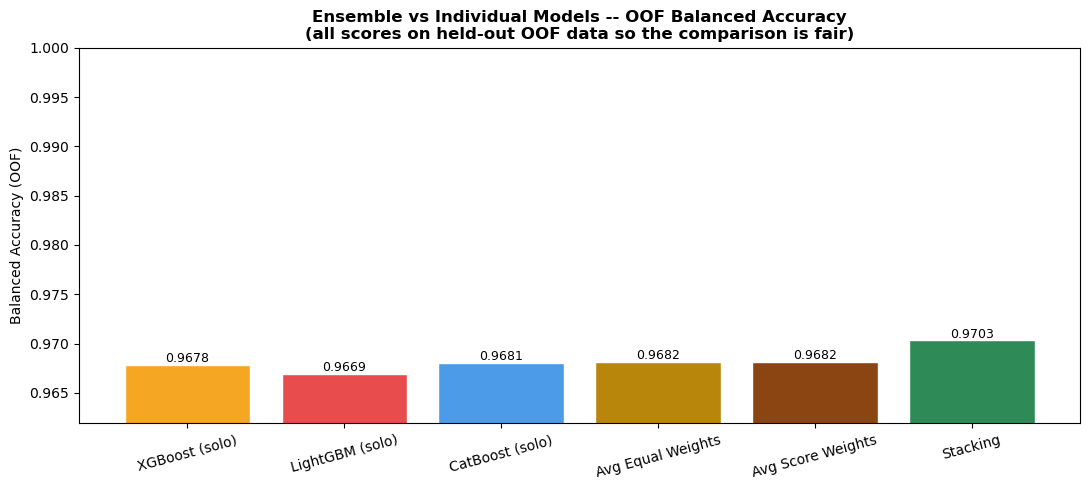

=== Final Comparison ===
Method                      OOF Balanced Acc
---------------------------------------------
XGBoost (solo)            0.9678
LightGBM (solo)           0.9669
CatBoost (solo)           0.9681
Avg Equal Weights         0.9682
Avg Score Weights         0.9682
Stacking                  0.9703

Best method:              Stacking (0.9703)
Best individual model:    0.9681
Improvement over solo:    +0.0022


In [27]:
methods = {
    'XGBoost (solo)':     f1_xgb,
    'LightGBM (solo)':    f1_lgb,
    'CatBoost (solo)':    f1_cat,
    'Avg Equal Weights':  f1_avg_eq,
    'Avg Score Weights':  f1_avg_wtd,
    'Stacking':           f1_stack,
}

colors = [
    '#F5A623', '#E84C4C', '#4C9BE8',
    '#B8860B', '#8B4513',
    '#2E8B57'
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(methods.keys(), methods.values(),
              color=colors, edgecolor='white')
ax.set_ylim(min(methods.values()) - 0.005, 1.0)
ax.set_ylabel('Balanced Accuracy (OOF)')
ax.set_title(
    'Ensemble vs Individual Models -- OOF Balanced Accuracy\n'
    '(all scores on held-out OOF data so the comparison is fair)',
    fontweight='bold'
)
ax.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, methods.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('=== Final Comparison ===')
print(f'{"Method":<25} {"OOF Balanced Acc":>18}')
print('-' * 45)
for method, score in methods.items():
    print(f'{method:<25} {score:.4f}')

best_method  = max(methods, key=methods.get)
best_score   = methods[best_method]
best_solo    = max(f1_xgb, f1_lgb, f1_cat)
improvement  = best_score - best_solo

print(f'\nBest method:              {best_method} ({best_score:.4f})')
print(f'Best individual model:    {best_solo:.4f}')
print(f'Improvement over solo:    {improvement:+.4f}')

## 11. Final Meta-Model and Submission

In [28]:
# Train the final meta-model on all OOF training data
sw_full    = compute_sample_weight('balanced', y)
final_meta = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
final_meta.fit(meta_train, y, sample_weight=sw_full)

# Generate final test predictions from the stacked meta-features
final_probs = final_meta.predict_proba(meta_test)
final_preds = np.argmax(final_probs, axis=1)

# If averaging outperformed stacking, swap in this line instead:
# final_preds = np.argmax(
#     w_xgb * test_xgb_folds + w_lgb * test_lgb_folds + w_cat * test_cat_folds,
#     axis=1
# )

submission = pd.DataFrame({
    'id':   test['id'],
    TARGET: le.inverse_transform(final_preds)
})
submission.to_csv('submission_ensemble_stacking.csv', index=False)

print('Saved: submission_ensemble_stacking.csv')
print(submission[TARGET].value_counts())

Saved: submission_ensemble_stacking.csv
Irrigation_Need
Low       159684
Medium    100202
High       10114
Name: count, dtype: int64
